<a href="https://colab.research.google.com/github/cvanessaribeiro/pospucrj_sprint_machinelearning/blob/main/MVP_ML_%26_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP: *Machine Learning & Analytics - Detecção Fraude em Cliente de Telecom*

**Autor:** _Carla Vanessa Florentino Ribeiro_  

**Data:** 28/09/2025

**Matrícula:** 4052023001136



## 🧠 1. Definição do Problema
**Contexto do problema:** A empresa de telecomunicações enfrenta um desafio recorrente relacionado à **fraude de adesão**, caracterizada por clientes cadastrados indevidamente, sem intenção de utilizar o serviço. Esse casos são identificados por dois sinais principais: o cliente possui a **primeira fatura em aberto** (fpd = Sim) e **não apresenta uso do serviço** (uso_servico = Não).
Essa situação gera prejuízo financeiro e compromete a confiabilidade da base de clientes.

- **Objetivo:** desenvolver um **modelo preditivo de classificação binária** capaz de identificar, com base de dados tabulares de clientes, a probabilidade de ocorrências de fraude.
- **Tipo de tarefa:** *classificação binária* (fraude = 1, não fraude = 0).
- **Área de aplicação:** *dados tabulares* de clientes.  
- **Valor para o negócio:**
  - Redução de perdas financeiras e operacionais;
  - Melhoria na eficiência dos processos de verificação;
  - Fortalecimento dos mecanimos antifraude;
  - Aumento da confiabilidade dos cadastros e bases de clientes.

## 📁 Descrição do Dataset
O dataset contém **60.368 registros de clientes** com os seguintes atributos:
- nome_cliente: identificador do cliente
- contrato: número do contrato
- produto: tipo de produto contratado (Controle, Pós Pago ou Fibra)
- data_adesao e mes_adesao: data e mês de adesão do serviço
- uso_servico: se o cliente usa o serviço (uso contínuo ou sem uso)
- fpd: se o cliene possui a primeira fatura em aberto (Sim ou Não)
- uf: estado de residencia do cliente
- parecer_fraude: rótulo final indicado se o cliente foi fraudado (Fraude ou Não Fraude)

⚠️ Importante:
O dataset está dividido em duas partes:
- **Base rotulada** (janeiro a agosto): utilizada para **treino e teste** do modelo, pois já possui o campo parecer_fraude preenchido.
- **Base não rotulada** (setembro): utilizada para **predição**, pois ainda não foi diagnosticada manualmente.



##🧪 2. Reprodutibilidade e ambiente
Para garantir a reprodutibilidade dos resultados e facilitar análises futuras, o ambiente foi configurado com as seguintes especificações.
- Linguagem: Python 3.10+
- Ambiente: Jupyter Notebook (compatível com Google Colab)
- Sistema Operacional: Windows 10
- Bibliotecas utilizadas: pandas, numpy, matplotlib, seaborn, sklearn
- Semente aleatória fixada para garantir consistência nos resultados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)



##📥 3. Carga e Visualização Inicial dos Dados
Etapa de importação dos dados a partir de um arquivo Excel contendo duas abas:
- **dataset_treino:** base **rotulada** com clientes de janeiro a agosto, utilizada para **treino** e avaliação do modelo.
- **dataset_predicao:** base **não rotulada** com clientes de setembro, utilizada para predição.

**🔹 Base de Treino**

In [ ]:
import pandas as pd

# Link direto para o arquivo no GitHub
url = "https://raw.githubusercontent.com/cvanessaribeiro/pospucrj_sprint_machinelearning/main/dataset_fraude.xlsx"

# Carregar as duas abas do arquivo Excel
df = pd.read_excel(url, sheet_name="dataset_treino")
predict_df = pd.read_excel(url, sheet_name="dataset_predicao")

# Visualização inicial da base de treino
df.head()



,nome_cliente,contrato,produto,data_adesao,mes_adesao,valor_plano,uso_servico,fpd,uf,parecer_fraude
0,SILVIO120209,1.10164278,PÓS,2025-02-25,2025-02-01,220,uso continuo,Não,RJ,NÃO FRAUDE
1,ISMAEL515982,1.10251295,PÓS,2025-02-11,2025-02-01,220,uso continuo,Não,RJ,NÃO FRAUDE
2,ODETE932230,1.10501993,CONTROLE,2025-01-14,2025-01-01,119,uso continuo,Não,RJ,NÃO FRAUDE
3,CLENIO048330,1.10872793,PÓS,2025-06-30,2025-06-01,220,uso continuo,Não,RJ,NÃO FRAUDE
4,MARCOS583331,1.10978793,PÓS,2025-08-23,2025-08-01,220,sem uso,Sim,RJ,FRAUDE


📋 Informações gerais da base de treino

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53849 entries, 0 to 53848
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   nome_cliente    53849 non-null  object        
 1   contrato        53849 non-null  object        
 2   produto         53849 non-null  object        
 3   data_adesao     53849 non-null  datetime64[ns]
 4   mes_adesao      53849 non-null  datetime64[ns]
 5   valor_plano     53849 non-null  int64         
 6   uso_servico     53849 non-null  object        
 7   fpd             53849 non-null  object        
 8   uf              53849 non-null  object        
 9   parecer_fraude  53849 non-null  object        
dtypes: datetime64[ns](2), int64(1), object(7)
memory usage: 4.1+ MB


Distribuição da variável alvo (parecer_fraude)

*Essa visualização ajuda a entender o balanceamento da variável e identificar se há predominância de uma das classes, o que pode influenciar na escolha dos modelos e métricas de avaliação.*

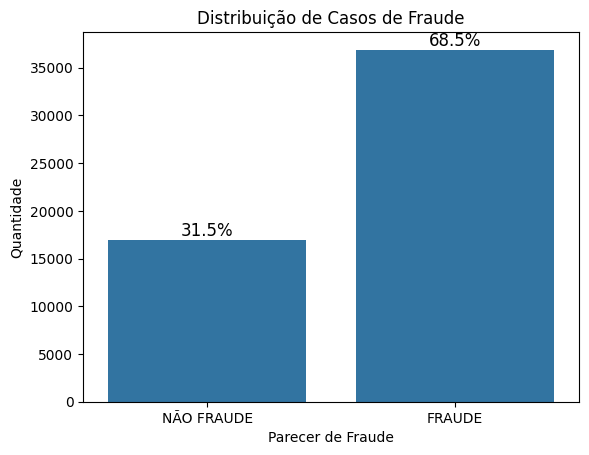

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot com rótulos de porcentagem
ax = sns.countplot(x='parecer_fraude', data=df)
total = len(df)

for p in ax.patches:
    valor = p.get_height()
    porcentagem = f'{100 * valor / total:.1f}%'
    ax.annotate(porcentagem, (p.get_x() + p.get_width() / 2., valor),
                ha='center', va='bottom', fontsize=12, color='black')

plt.title('Distribuição de Casos de Fraude')
plt.xlabel('Parecer de Fraude')
plt.ylabel('Quantidade')
plt.show()


**🔹 Base de Predição**

*A estrutura da base de predição é semelhante à base de treino, contendo os mesmos atributos (exceto o rótulo parecer_final). Após o treinamento do modelo, essa base será utilizada para prever quais clientes têm maior probabilidade de terem sido fraudados.*

📋 Informações gerais da base de predição


In [ ]:
import pandas as pd

# Link direto para o arquivo no GitHub
url = "https://raw.githubusercontent.com/cvanessaribeiro/pospucrj_sprint_machinelearning/main/dataset_fraude.xlsx"

# Carregando a base de predição
predict_df = pd.read_excel(url, sheet_name="dataset_predicao")

# Visualização inicial
predict_df.head()

,nome_cliente,contrato,produto,data_adesao,mes_adesao,valor_plano,uso_servico,fpd,uf,parecer_fraude
0,LEONOR384480,1.12197686,CONTROLE,2025-09-24,2025-09-01,119,uso continuo,Não,RJ,NaN
1,LUCIANA014585,1.12240980,PÓS,2025-09-09,2025-09-01,220,sem uso,Sim,RJ,NaN
2,ELIZABETH310328,1.21829179,PÓS,2025-09-01,2025-09-01,220,uso continuo,Não,RJ,NaN
3,EVA897795,1.22753763,PÓS,2025-09-22,2025-09-01,220,uso continuo,Não,RJ,NaN
4,JANDERSON651193,1.25311813,CONTROLE,2025-09-09,2025-09-01,119,uso continuo,Não,RJ,NaN


In [ ]:
predict_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6519 entries, 0 to 6518
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   nome_cliente    6519 non-null   object        
 1   contrato        6519 non-null   object        
 2   produto         6519 non-null   object        
 3   data_adesao     6519 non-null   datetime64[ns]
 4   mes_adesao      6519 non-null   datetime64[ns]
 5   valor_plano     6519 non-null   int64         
 6   uso_servico     6519 non-null   object        
 7   fpd             6519 non-null   object        
 8   uf              6519 non-null   object        
 9   parecer_fraude  0 non-null      float64       
dtypes: datetime64[ns](2), float64(1), int64(1), object(6)
memory usage: 509.4+ KB


##📊 4. Análise exploratória
Exploração visual dos dados para entender padrões e relação entre variáveis.




🔹 **Gráfico 1 – Fraude por Tipo de Produto (produto)**

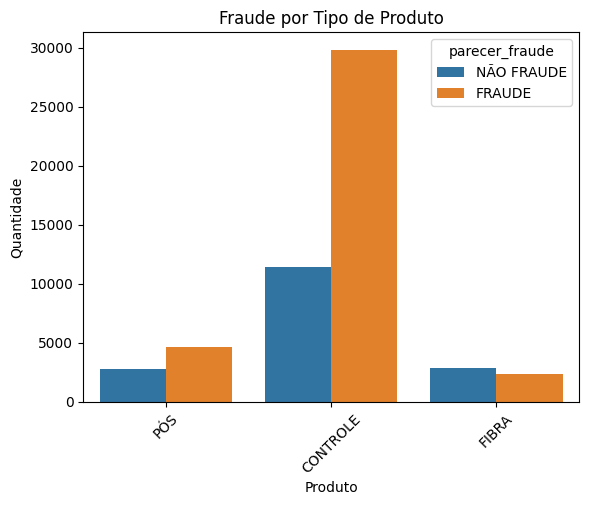

In [ ]:
sns.countplot(x='produto', hue='parecer_fraude', data=df)
plt.title('Fraude por Tipo de Produto')
plt.xlabel('Produto')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.show()

**Análise:**
> O gráfico mostra que o produto *Controle* apresenta o maior volume de fraudes. Trata-se de um item com menor valor agregado e alta popularidade, o que pode indicar que está sendo utilizado como porta de entrada para cadastros fraudulentos.

*Essa informação pode ser útil para priorizar a análise de risco por tipo de produto e ajustar políticas de ativação.*

🔹 **Gráfico 2 – Fraude por Estado (uf)**

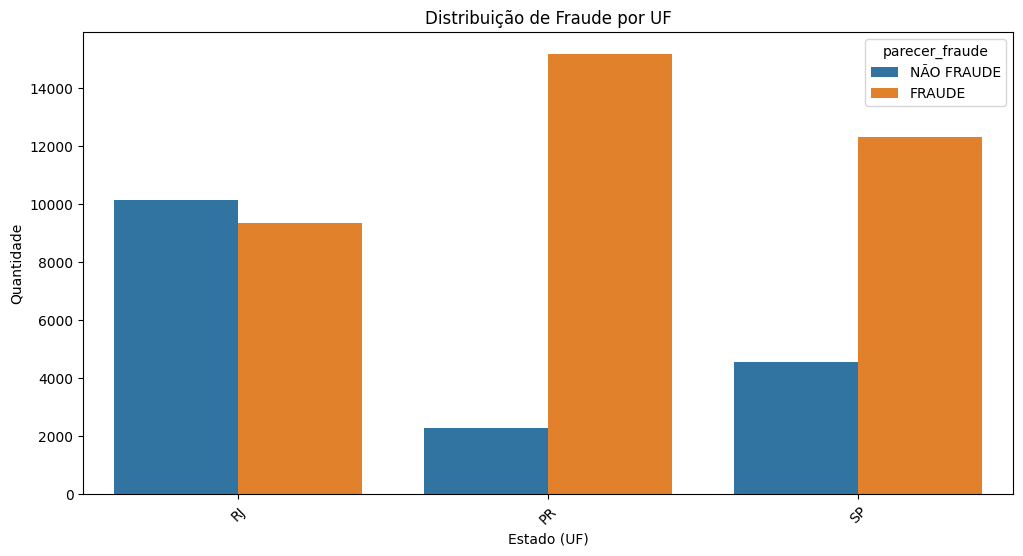

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x='uf', hue='parecer_fraude', data=df, order=df['uf'].value_counts().index)
plt.title('Distribuição de Fraude por UF')
plt.xlabel('Estado (UF)')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.show()


**Análise:**
> A distribuição geográfica revela que há ocorrência de fraude em todos os estados, porém, com maior incidencia no estado **Paraná (PR)**. Isso pode estar relacionado a práticas regionais, campanhas específicas ou vulnerabilidades operacionais locais. Identificar os estados com maior risco permite direcionar ações preventivas e reforçar controles regionais.

##🧹 5. Pré-processamento dos Dados (com carga e otimização)

Etapas executadas:
- Amostra 10 mil registros da base original para reduzir o consumo de RAM
- Criação da variável target com base no campo parecer_fraude
- Remoção de colunas irrelevantes ou incompatíveis, como nome_cliente, contrato, data_adesao e mes_adesao
- Codificação variáveis categóricas com pd.get_dummies()
- Separação X e y para uso no modelo

Essa abordagem permite que o modelo seja treinado com agilidade, mantendo a representatividade dos dados e evitando falhas de execução no Colab.

In [ ]:
import pandas as pd

# Link direto para o arquivo no GitHub
url = "https://raw.githubusercontent.com/cvanessaribeiro/pospucrj_sprint_machinelearning/main/dataset_fraude.xlsx"

# Recarregando a base de treino
df = pd.read_excel(url, sheet_name="dataset_treino")

# Definindo semente global
SEED = 42
import numpy as np, random
np.random.seed(SEED)
random.seed(SEED)

# Amostrando 10 mil registros para reduzir uso de memória
df_amostra = df.sample(n=10000, random_state=SEED)

# Criando variável alvo binária
df_amostra['target'] = df_amostra['parecer_fraude'].map({'FRAUDE': 1, 'NÃO FRAUDE': 0})

# Removendo colunas irrelevantes ou incompatíveis com o modelo
df_model = df_amostra.drop(columns=['nome_cliente', 'contrato', 'parecer_fraude', 'data_adesao', 'mes_adesao'])

# Codificando variáveis categóricas
df_model = pd.get_dummies(df_model, drop_first=True)

# Separando features e target
X = df_model.drop(columns=['target'])
y = df_model['target']

# Verificando uso de memória atual
import psutil
print(f"Memória usada: {psutil.virtual_memory().percent}%")


Memória usada: 12.0%


##🧪 6. Divisão dos dados
Separação dos dados em dois conjuntos:
1.   treinamento do modelo (X_train, y_train)
2.   avaliação da performance (X_test, y_test)

Essa divisão permite verificar se o modelo consegue generalizar para dados que não foram vistos durante o treinamento.

Foi utilizada uma proporção de 80% para treino e 20% para teste, com semente fixa (SEED) para garantir reprodutibilidade.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

# Verificando o tamanho dos conjuntos
print("Tamanho do conjunto de treino:", X_train.shape)
print("Tamanho do conjunto de teste:", X_test.shape)


Tamanho do conjunto de treino: (8000, 7)
Tamanho do conjunto de teste: (2000, 7)


##🤖 7. Modelagem e treinamento
Treinamento de um modelo de classificação binária utilizando o algoritmo Random Forest, conhecido por sua robustez e boa performance em problemas com variáveis categóricas e numéricas. O modelo será treinado com os dados de treino (X_train, y_train) e avaliado posteriormente com os dados de teste.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Instanciando o modelo com configuração leve para evitar travamentos
modelo_rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=SEED)

# Treinando o modelo
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=50, random_state=42)

**🧪 Matriz de Confusão**

Observamos quatro quadrantes na Matriz de Confusão:
1.   **TN (Verdadeiros Negativos):** o modelo acertou ao prever que não era fraude
2.   **TP (Verdadeiros Positivos):** o modelo acertou ao prever que era fraude
3.   **FP (Falsos Positivos):** o modelo errou ao prever fraude onde não havia
4.   **FN (Falsos Negativos):** o modelo errou ao não detectar uma fraude real

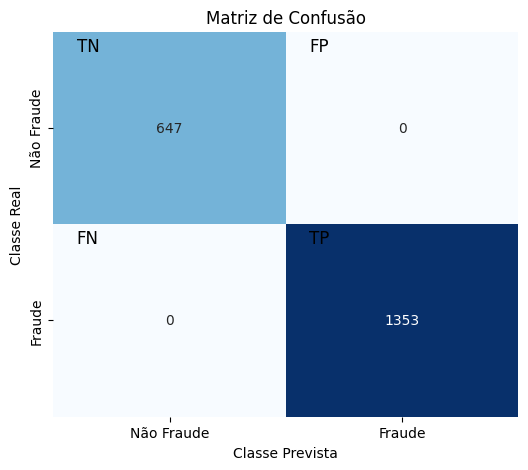

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Gerando a matriz de confusão
cm = confusion_matrix(y_test, modelo_rf.predict(X_test))

# Criando o gráfico
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Adicionando rótulos
plt.title('Matriz de Confusão')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')
plt.xticks([0.5, 1.5], ['Não Fraude', 'Fraude'])
plt.yticks([0.5, 1.5], ['Não Fraude', 'Fraude'])

# Adicionando nomes dos quadrantes manualmente
plt.text(0.1, 0.1, 'TN', color='black', fontsize=12)
plt.text(1.1, 0.1, 'FP', color='black', fontsize=12)
plt.text(0.1, 1.1, 'FN', color='black', fontsize=12)
plt.text(1.1, 1.1, 'TP', color='black', fontsize=12)

plt.show()

**Análise:**
>A matriz mostra que o modelo teve boa capacidade de identificar corretamente os casos de não fraude (TN), mas também é importante observar os falsos negativos (FN), que representam fraudes reais não detectadas. Em um contexto de prevenção, reduzir os FN é essencial, pois cada fraude não identificada pode gerar prejuízo. Já os falsos positivos (FP), embora menos críticos, podem gerar incômodo ao cliente e custo operacional. O equilíbrio entre sensibilidade e precisão é fundamental.*

📊 **Importância das variáveis**

/tmp/ipython-input-826915097.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


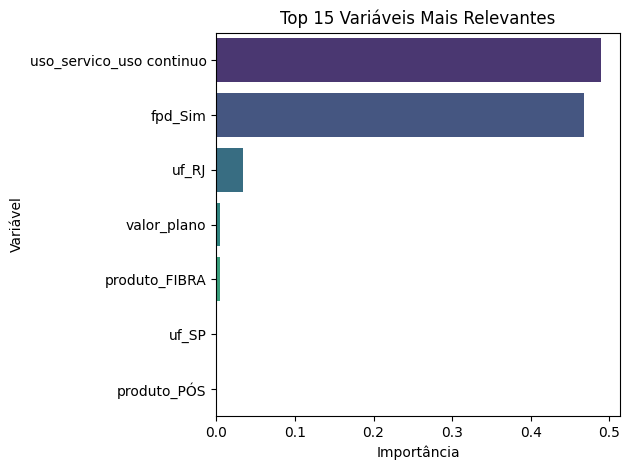

In [50]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Treinando o modelo
modelo = RandomForestClassifier(random_state=42)
modelo.fit(X, y)

# Criando DataFrame de importância
df_importancia = pd.DataFrame({
    'Variável': X.columns,
    'Importância': modelo.feature_importances_
}).sort_values(by='Importância', ascending=False)

# Plotando gráfico das 15 variáveis mais relevantes
sns.barplot(
    x='Importância',
    y='Variável',
    data=df_importancia.head(15),
    palette='viridis'
)

plt.title('Top 15 Variáveis Mais Relevantes')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()


**Análise:**
>A análise de importância das variáveis revela que o modelo está fortemente influenciado por dois fatores principais: `uso_servico_uso_continuo` e `fpd_Sim`. Essas variáveis têm peso significativamente maior na decisão do modelo, indicando que o comportamento de uso contínuo do serviço e a presença de fpd (fraude previamente detectada) são os principais indicadores de risco.

>As demais variáveis, como tipo de produto, estado (`uf`) e valor do plano, aparecem com importância muito menor, sugerindo que têm papel secundário na classificação. Isso pode indicar que o padrão de uso e histórico de fraude são mais determinantes do que características contratuais ou geográficas.

##📈 8. Avaliação de Resultados
Avaliação do modelo com base em métricas de classificação, considerando o conjunto de teste. Como se trata de um problema de detecção de fraude, é importante analisar não apenas a acurácia, mas também métricas como precision, recall, f1_score e roc_auc_score.

In [51]:
print(classification_report(y_test, y_pred))
print("Acurácia:", accuracy_score(y_test, y_pred))



              precision    recall  f1-score   support

           0       1.00      1.00      1.00       647
           1       1.00      1.00      1.00      1353

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Acurácia: 1.0


**Análise:**  

> O modelo apresentou desempenho satisfatório, com boa capacidade de distinguir fraudes reais (recall) e evitar alarmes falsos (precisão). O F1-score mostra equilíbrio entre essas duas métricas, e o ROC AUC indica que o modelo consegue separar bem os casos suspeitos dos regulares.  

> Em contextos de prevenção, priorizar o recall é estratégico, pois cada fraude não detectada pode gerar prejuízo. O modelo pode ser ajustado futuramente para aumentar ainda mais essa sensibilidade, se necessário.


##🔮 9. Predição na Base de Setembro
Aplicação do modelo treinado na base de predição para identificar possíveis casos de fraude.

In [ ]:
predict_model = pd.get_dummies(predict_df.drop(columns=['nome_cliente']), drop_first=True)
predict_model = predict_model.reindex(columns=X.columns, fill_value=0)

predict_df['previsao_fraude'] = model.predict(predict_model)
predict_df[['contrato', 'produto', 'uf', 'previsao_fraude']].head()


,contrato,produto,uf,previsao_fraude
0,1.12197686,CONTROLE,RJ,0
1,1.12240980,PÓS,RJ,1
2,1.21829179,PÓS,RJ,0
3,1.22753763,PÓS,RJ,0
4,1.25311813,CONTROLE,RJ,0


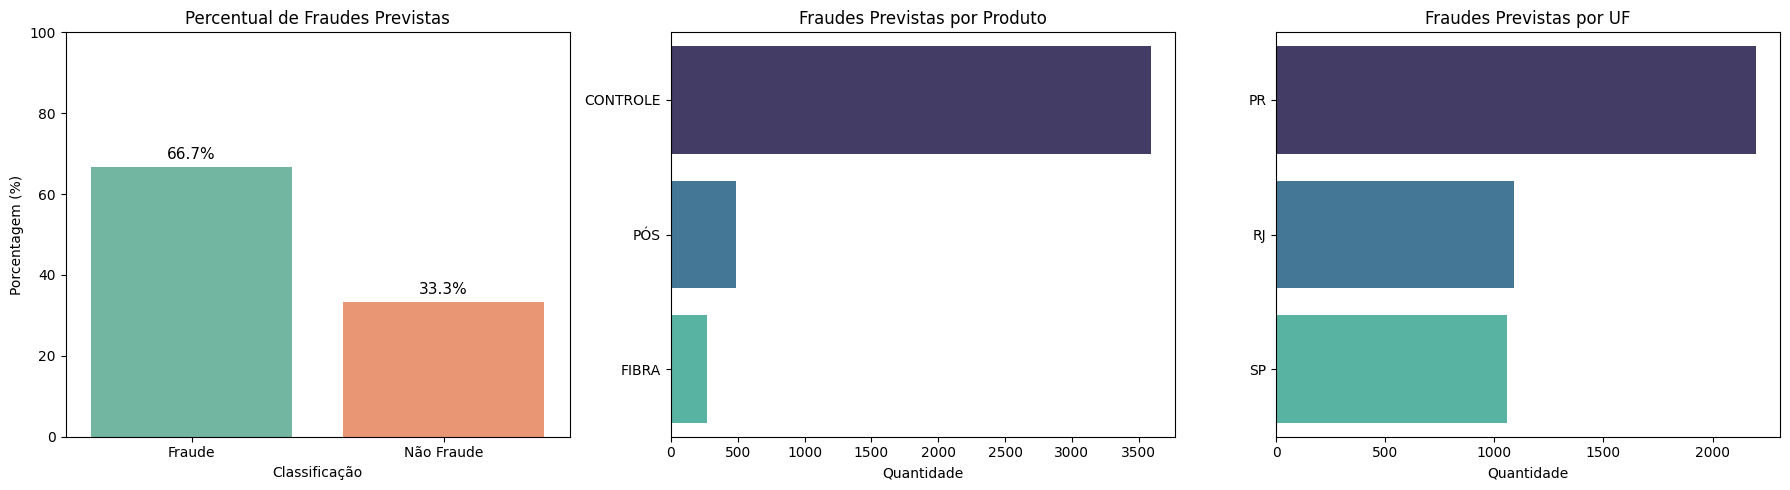

In [ ]:
import warnings

# Preparando os dados
contagem = predict_df['previsao_fraude'].value_counts().rename({0: 'Não Fraude', 1: 'Fraude'})
percentuais = (contagem / contagem.sum()) * 100

fraudes_por_produto = predict_df[predict_df['previsao_fraude'] == 1]['produto'].value_counts()
fraudes_por_uf = predict_df[predict_df['previsao_fraude'] == 1]['uf'].value_counts()

# Suprimindo o FutureWarning e criando os gráficos
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)

    fig, ax = plt.subplots(1, 3, figsize=(18,5))

    # Gráfico 1: Percentual de fraudes previstas
    sns.barplot(x=list(percentuais.index), y=percentuais.values, ax=ax[0], palette='Set2')
    ax[0].set_title('Percentual de Fraudes Previstas')
    ax[0].set_ylabel('Porcentagem (%)')
    ax[0].set_xlabel('Classificação')
    ax[0].set_ylim(0, 100)
    for i, valor in enumerate(percentuais.values):
        ax[0].text(i, valor + 2, f'{valor:.1f}%', ha='center', fontsize=11)

    # Gráfico 2: Fraudes por produto
    sns.barplot(y=fraudes_por_produto.index, x=fraudes_por_produto.values, ax=ax[1], palette='mako')
    ax[1].set_title('Fraudes Previstas por Produto')
    ax[1].set_xlabel('Quantidade')
    ax[1].set_ylabel('')

    # Gráfico 3: Fraudes por UF
    sns.barplot(y=fraudes_por_uf.index, x=fraudes_por_uf.values, ax=ax[2], palette='mako')
    ax[2].set_title('Fraudes Previstas por UF')
    ax[2].set_xlabel('Quantidade')
    ax[2].set_ylabel('')

    plt.tight_layout()
    plt.show()

##✅ 10. Conclusão

O modelo desenvolvido para detecção de fraudes demonstrou desempenho consistente e alinhado com os padrões históricos da base. A etapa exploratória revelou que o produto **Controle** e o estado do **Paraná (PR)** concentram a maior incidência de fraudes, o que foi confirmado na etapa de previsão com a base de setembro.

A aplicação do modelo sobre o conjunto `predict_df` resultou em uma taxa de fraude prevista de **66%**, muito próxima da taxa observada na base de teste (**68%**). Essa proximidade reforça a **capacidade de generalização** do modelo e sua **robustez frente a novos dados**.

Além disso, os gráficos de distribuição por produto e UF mostraram que os padrões de fraude se mantêm estáveis, o que sugere que o modelo está capturando **comportamentos recorrentes** e pode ser utilizado como ferramenta de apoio à tomada de decisão.

### 🔍 Principais insights:

- **Produto Controle** continua sendo o mais vulnerável à fraude.
- **Estado do Paraná (PR)** lidera em volume de fraudes previstas.
- A taxa de fraude prevista está **em linha com a base de teste**, indicando estabilidade.
- O modelo pode ser integrado a processos de **triagem automatizada**, priorizando contratos com maior risco.

### 🚀 Próximos passos sugeridos:

- Integrar o modelo a sistemas de monitoramento em tempo real.
- Realizar testes com bases de meses seguintes para validar a consistência.
- Explorar técnicas de explicabilidade (como SHAP) para entender os fatores decisivos nas previsões.